# 🛡️ Fraud Detection — Complete Training Notebook

**Techniques covered:**
- 🌲 **Random Forest** — Ensemble classification baseline
- ⚡ **XGBoost** — Gradient boosting with scale_pos_weight
- 🔁 **SMOTE** — Synthetic oversampling for class imbalance
- 🔍 **Isolation Forest** — Unsupervised anomaly detection

**Datasets:**
1. `Fraudulent_E-Commerce_Transaction_Data_2.csv` — E-commerce transactions (23,634 rows)
2. `transactions.csv` — Bank transactions (299,695 rows)
3. `creditcard.csv` — Credit card transactions / PCA features (284,807 rows)

## 📦 0. Install & Import Libraries

In [1]:
# Install if running for the first time
# !pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', palette='muted')
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


---
## 📂 1. Load All Three Datasets

In [2]:
df_ecom = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data_2.csv')
df_txn  = pd.read_csv('transactions.csv')
df_cc   = pd.read_csv('creditcard.csv')

print('E-Commerce shape  :', df_ecom.shape)
print('Transactions shape:', df_txn.shape)
print('Credit Card shape :', df_cc.shape)

E-Commerce shape  : (23634, 16)
Transactions shape: (299695, 17)
Credit Card shape : (284807, 31)


---
## 🔍 2. Exploratory Data Analysis

### 2.1 Class Imbalance — All Datasets

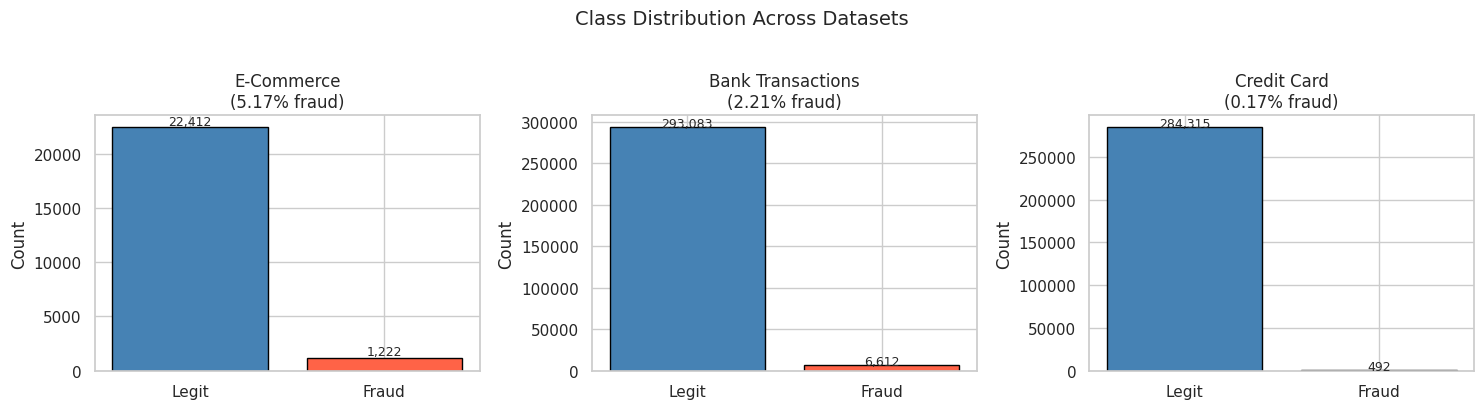

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (df_ecom, 'Is Fraudulent', 'E-Commerce'),
    (df_txn,  'is_fraud',      'Bank Transactions'),
    (df_cc,   'Class',         'Credit Card'),
]

for ax, (df, target, title) in zip(axes, datasets):
    counts = df[target].value_counts()
    ax.bar(['Legit', 'Fraud'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(f'{title}\n({counts[1]/len(df)*100:.2f}% fraud)', fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Class Distribution Across Datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 E-Commerce Dataset — Quick EDA

In [4]:
df_ecom.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,c12e07a0-8a06-4c0d-b5cc-04f3af688570,8ca9f102-02a4-4207-ab63-484e83a1bdf0,42.32,2024-03-24 23:42:43,PayPal,electronics,1,40,East Jameshaven,desktop,110.87.246.85,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,0,282,23
1,7d187603-7961-4fce-9827-9698e2b6a201,4d158416-caae-4b09-bd5b-15235deb9129,301.34,2024-01-22 00:53:31,credit card,electronics,3,35,Kingstad,tablet,14.73.104.153,"5230 Stephanie Forge\nCollinsbury, PR 81853","5230 Stephanie Forge\nCollinsbury, PR 81853",0,223,0
2,f2c14f9d-92df-4aaf-8931-ceaf4e63ed72,ccae47b8-75c7-4f5a-aa9e-957deced2137,340.32,2024-01-22 08:06:03,debit card,toys & games,5,29,North Ryan,desktop,67.58.94.93,"195 Cole Oval\nPort Larry, IA 58422","4772 David Stravenue Apt. 447\nVelasquezside, ...",0,360,8
3,e9949bfa-194d-486b-84da-9565fca9e5ce,b04960c0-aeee-4907-b1cd-4819016adcef,95.77,2024-01-16 20:34:53,credit card,electronics,5,45,Kaylaville,mobile,202.122.126.216,"7609 Cynthia Square\nWest Brenda, NV 23016","7609 Cynthia Square\nWest Brenda, NV 23016",0,325,20
4,7362837c-7538-434e-8731-0df713f5f26d,de9d6351-b3a7-4bc7-9a55-8f013eb66928,77.45,2024-01-16 15:47:23,credit card,clothing,5,42,North Edwardborough,desktop,96.77.232.76,"2494 Robert Ramp Suite 313\nRobinsonport, AS 5...","2494 Robert Ramp Suite 313\nRobinsonport, AS 5...",0,116,15


In [5]:
df_ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      23634 non-null  object 
 1   Customer ID         23634 non-null  object 
 2   Transaction Amount  23634 non-null  float64
 3   Transaction Date    23634 non-null  object 
 4   Payment Method      23634 non-null  object 
 5   Product Category    23634 non-null  object 
 6   Quantity            23634 non-null  int64  
 7   Customer Age        23634 non-null  int64  
 8   Customer Location   23634 non-null  object 
 9   Device Used         23634 non-null  object 
 10  IP Address          23634 non-null  object 
 11  Shipping Address    23634 non-null  object 
 12  Billing Address     23634 non-null  object 
 13  Is Fraudulent       23634 non-null  int64  
 14  Account Age Days    23634 non-null  int64  
 15  Transaction Hour    23634 non-null  int64  
dtypes: f

In [5]:
df_ecom.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000
mean,229.367099,3.000550,34.560210,0.051705,178.660531,11.266015
std,282.046669,1.419663,10.009471,0.221436,107.388682,6.980659
min,10.000000,1.000000,-2.000000,0.000000,1.000000,0.000000
25%,69.070000,2.000000,28.000000,0.000000,84.000000,5.000000
50%,151.415000,3.000000,35.000000,0.000000,178.000000,11.000000
75%,296.127500,4.000000,41.000000,0.000000,272.000000,17.000000
max,9716.500000,5.000000,73.000000,1.000000,365.000000,23.000000


In [6]:
# Missing values
print('Missing values per column:\n', df_ecom.isnull().sum())

Missing values per column:
 Transaction ID        0
Customer ID           0
Transaction Amount    0
Transaction Date      0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Customer Location     0
Device Used           0
IP Address            0
Shipping Address      0
Billing Address       0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64


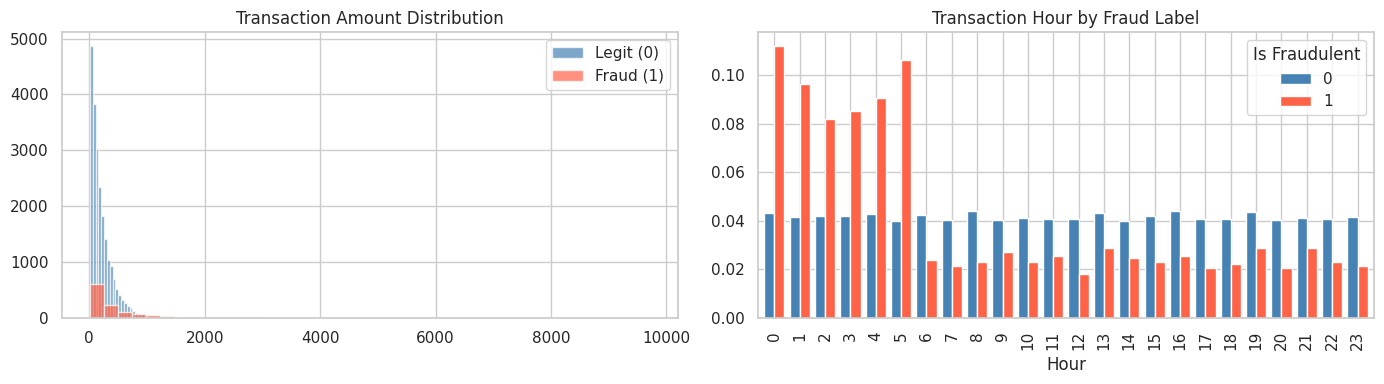

In [7]:
# Transaction Amount by fraud status
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Legit (0)', 1: 'Fraud (1)'}

for label, group in df_ecom.groupby('Is Fraudulent'):
    group['Transaction Amount'].hist(
        bins=40, ax=axes[0], alpha=0.7,
        color=colors[label], label=labels[label]
    )
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()

df_ecom.groupby('Is Fraudulent')['Transaction Hour'].value_counts(normalize=True).unstack(0).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], width=0.8
)
axes[1].set_title('Transaction Hour by Fraud Label')
axes[1].set_xlabel('Hour')
plt.tight_layout()
plt.show()

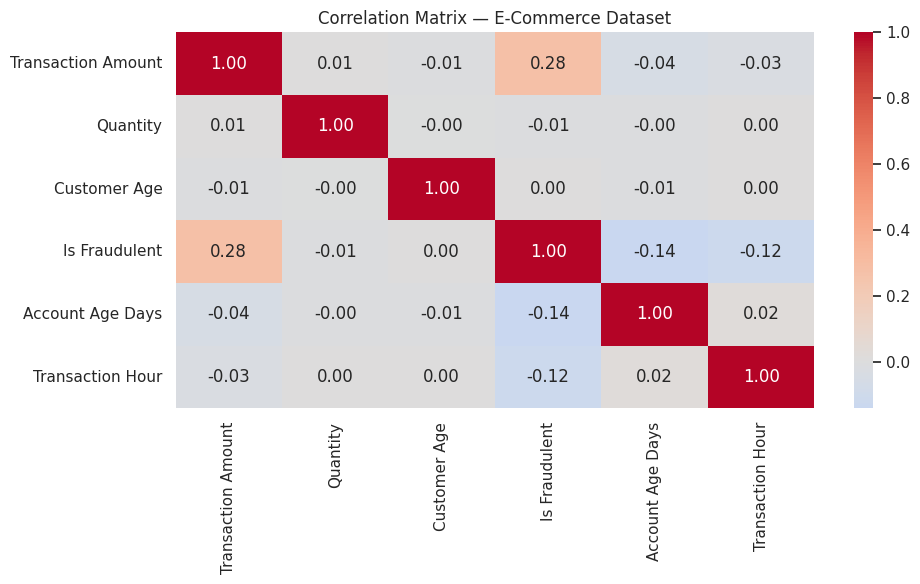

In [8]:
# Correlation heatmap — numeric only
numeric_cols = df_ecom.select_dtypes(include='number')
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — E-Commerce Dataset')
plt.tight_layout()
plt.show()

### 2.3 Credit Card Dataset — Amount & Time Patterns

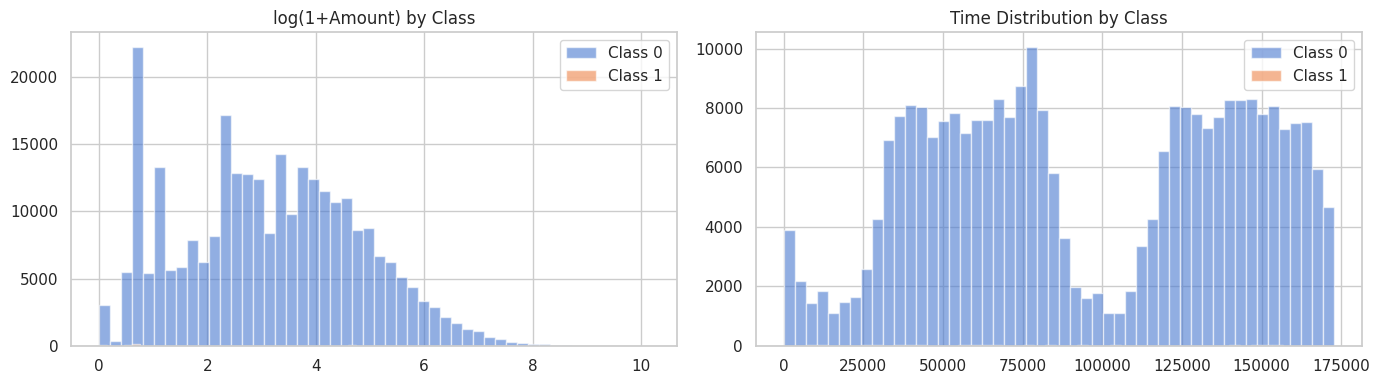

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount distribution
for label, group in df_cc.groupby('Class'):
    axes[0].hist(np.log1p(group['Amount']), bins=50, alpha=0.6, label=f'Class {label}')
axes[0].set_title('log(1+Amount) by Class')
axes[0].legend()

# Time distribution
for label, group in df_cc.groupby('Class'):
    axes[1].hist(group['Time'], bins=50, alpha=0.6, label=f'Class {label}')
axes[1].set_title('Time Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🛠️ 3. Preprocessing

### 3.1 Preprocess E-Commerce Dataset

In [10]:
df = df_ecom.copy()

# Drop ID and high-cardinality columns
drop_cols = ['Transaction ID', 'Customer ID', 'Transaction Date', 'IP Address',
             'Shipping Address', 'Billing Address', 'Customer Location']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Encode categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Split features and target
X_ecom = df.drop('Is Fraudulent', axis=1)
y_ecom = df['Is Fraudulent']

print('\nFeatures shape:', X_ecom.shape)
print('Fraud rate    :', y_ecom.mean().round(4))

Categorical columns: ['Payment Method', 'Product Category', 'Device Used']

Features shape: (23634, 8)
Fraud rate    : 0.0517


### 3.2 Preprocess Transactions Dataset

In [11]:
df2 = df_txn.copy()
df2.drop(columns=['transaction_id', 'user_id', 'transaction_time'], inplace=True, errors='ignore')

cat_cols2 = df2.select_dtypes(include='object').columns.tolist()
for col in cat_cols2:
    df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))

X_txn = df2.drop('is_fraud', axis=1)
y_txn = df2['is_fraud']

print('Transactions features:', X_txn.shape)
print('Fraud rate:', y_txn.mean().round(4))

Transactions features: (299695, 13)
Fraud rate: 0.0221


### 3.3 Preprocess Credit Card Dataset

In [12]:
df3 = df_cc.copy()

# Scale Amount and Time (V1-V28 already PCA-transformed)
scaler = StandardScaler()
df3['scaled_amount'] = scaler.fit_transform(df3[['Amount']])
df3['scaled_time']   = scaler.fit_transform(df3[['Time']])
df3.drop(columns=['Amount', 'Time'], inplace=True)

X_cc = df3.drop('Class', axis=1)
y_cc = df3['Class']

print('Credit card features:', X_cc.shape)
print('Fraud rate:', y_cc.mean().round(6))

Credit card features: (284807, 30)
Fraud rate: 0.001727


### 3.4 Train/Test Split (Stratified)

In [13]:
def stratified_split(X, y, test_size=0.2, seed=42):
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)

X_ecom_tr, X_ecom_te, y_ecom_tr, y_ecom_te = stratified_split(X_ecom, y_ecom)
X_txn_tr,  X_txn_te,  y_txn_tr,  y_txn_te  = stratified_split(X_txn, y_txn)
X_cc_tr,   X_cc_te,   y_cc_tr,   y_cc_te   = stratified_split(X_cc, y_cc)

print('E-Commerce  train/test:', X_ecom_tr.shape, X_ecom_te.shape)
print('Transactions train/test:', X_txn_tr.shape, X_txn_te.shape)
print('Credit Card  train/test:', X_cc_tr.shape, X_cc_te.shape)

E-Commerce  train/test: (18907, 8) (4727, 8)
Transactions train/test: (239756, 13) (59939, 13)
Credit Card  train/test: (227845, 30) (56962, 30)


---
## 🔁 4. SMOTE — Synthetic Minority Oversampling

SMOTE creates **synthetic** minority-class samples by interpolating between existing ones, rather than simply duplicating them.

> ⚠️ **Always fit SMOTE on training data only!** Never apply it to test data.

In [14]:
smote = SMOTE(random_state=42)

X_ecom_sm, y_ecom_sm = smote.fit_resample(X_ecom_tr, y_ecom_tr)
X_txn_sm,  y_txn_sm  = smote.fit_resample(X_txn_tr, y_txn_tr)
X_cc_sm,   y_cc_sm   = smote.fit_resample(X_cc_tr, y_cc_tr)

print('--- After SMOTE ---')
print('E-Commerce  :', dict(zip(*np.unique(y_ecom_sm, return_counts=True))))
print('Transactions:', dict(zip(*np.unique(y_txn_sm, return_counts=True))))
print('Credit Card :', dict(zip(*np.unique(y_cc_sm, return_counts=True))))

--- After SMOTE ---
E-Commerce  : {np.int64(0): np.int64(17929), np.int64(1): np.int64(17929)}
Transactions: {np.int64(0): np.int64(234466), np.int64(1): np.int64(234466)}
Credit Card : {np.int64(0): np.int64(227451), np.int64(1): np.int64(227451)}


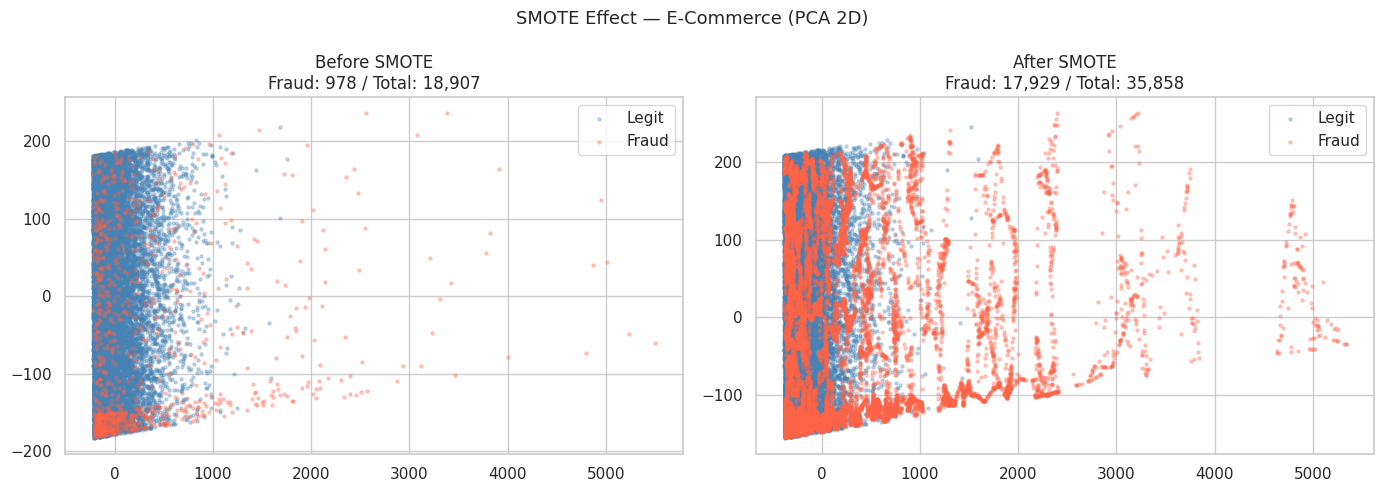

In [15]:
# Visualise before/after SMOTE for E-Commerce (2D PCA projection)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X, y, title in [
    (axes[0], X_ecom_tr, y_ecom_tr, 'Before SMOTE'),
    (axes[1], X_ecom_sm, y_ecom_sm, 'After SMOTE'),
]:
    proj = pca.fit_transform(X)
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = y == label
        ax.scatter(proj[mask, 0], proj[mask, 1], c=color, alpha=0.3,
                   label='Legit' if label == 0 else 'Fraud', s=5)
    ax.set_title(f'{title}\nFraud: {mask.sum():,} / Total: {len(y):,}')
    ax.legend()

plt.suptitle('SMOTE Effect — E-Commerce (PCA 2D)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🌲 5. Random Forest

### 5.1 Helpers — Evaluation

In [21]:
def evaluate_model(model, X_test, y_test, model_name='Model', dataset_name=''):
    """Print metrics + plot ROC and PR curves."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    avg_prc = average_precision_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)

    #print(f'\n{'='*55'}')
    print(f'{model_name} | {dataset_name}')
    #print(f'{'='*55'}')
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    print(f'ROC-AUC : {roc_auc:.4f}')
    print(f'Avg Prec: {avg_prc:.4f}')
    print(f'F1 Score: {f1:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0],
                                            display_labels=['Legit', 'Fraud'], cmap='Blues')
    axes[0].set_title('Confusion Matrix')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc_auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC Curve'); axes[1].legend()

    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[2].plot(rec, prec, color='steelblue', lw=2, label=f'AP={avg_prc:.3f}')
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

    plt.suptitle(f'{model_name} — {dataset_name}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'dataset': dataset_name,
            'roc_auc': roc_auc, 'avg_precision': avg_prc, 'f1': f1}


def plot_feature_importance(model, feature_names, top_n=15, title='Feature Importance'):
    imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(top_n)
    plt.figure(figsize=(9, 5))
    imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(title)
    plt.tight_layout()
    plt.show()

results = []

### 5.2 Random Forest — E-Commerce (No SMOTE baseline)

Random Forest (balanced) | E-Commerce
              precision    recall  f1-score   support

       Legit       0.97      0.94      0.95      4483
       Fraud       0.28      0.42      0.33       244

    accuracy                           0.91      4727
   macro avg       0.62      0.68      0.64      4727
weighted avg       0.93      0.91      0.92      4727

ROC-AUC : 0.8100
Avg Prec: 0.2682
F1 Score: 0.3344


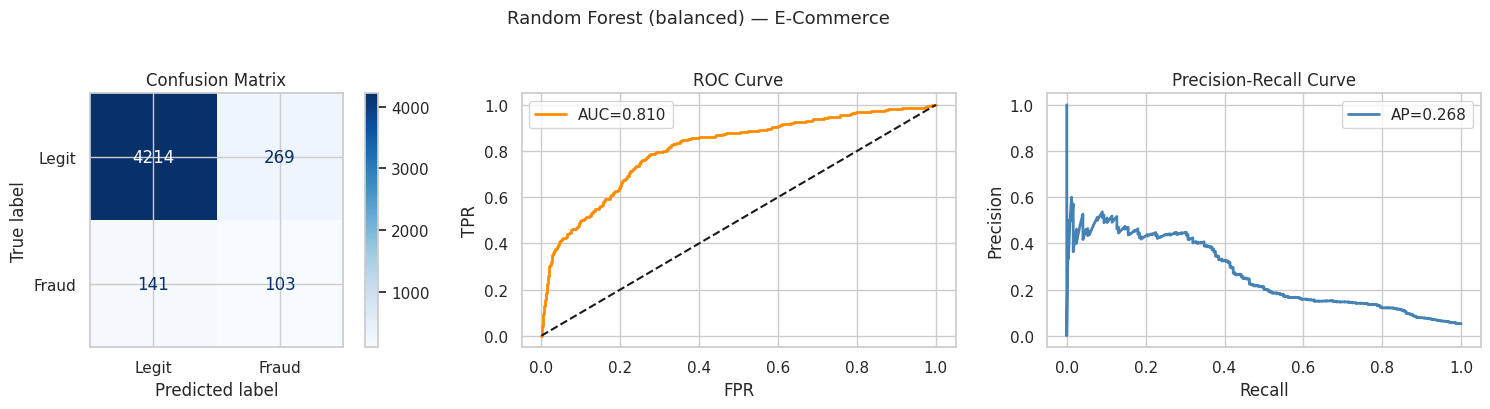

In [22]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # handles imbalance without SMOTE
    n_jobs=-1,
    random_state=42
)
rf_base.fit(X_ecom_tr, y_ecom_tr)

r = evaluate_model(rf_base, X_ecom_te, y_ecom_te, 'Random Forest (balanced)', 'E-Commerce')
results.append(r)

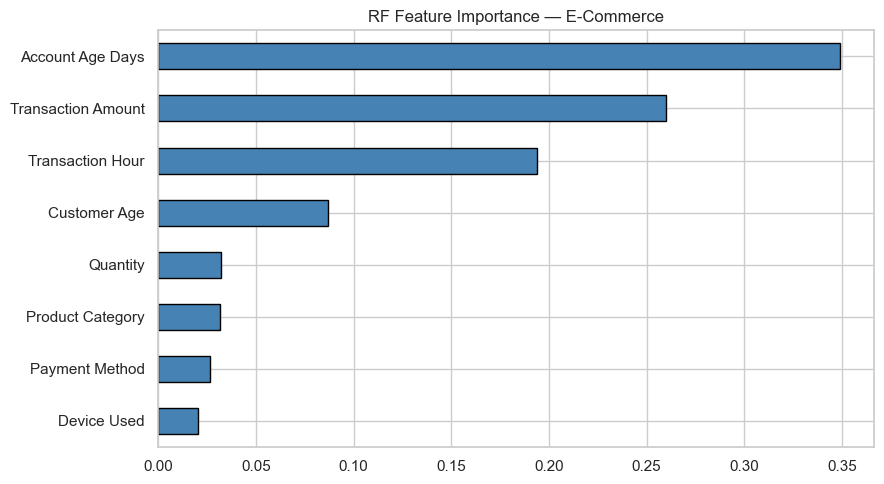

In [21]:
plot_feature_importance(rf_base, X_ecom.columns, title='RF Feature Importance — E-Commerce')

### 5.3 Random Forest — E-Commerce (With SMOTE)

Random Forest + SMOTE | E-Commerce
              precision    recall  f1-score   support

       Legit       0.97      0.86      0.91      4483
       Fraud       0.15      0.46      0.23       244

    accuracy                           0.84      4727
   macro avg       0.56      0.66      0.57      4727
weighted avg       0.93      0.84      0.88      4727

ROC-AUC : 0.7489
Avg Prec: 0.2255
F1 Score: 0.2299


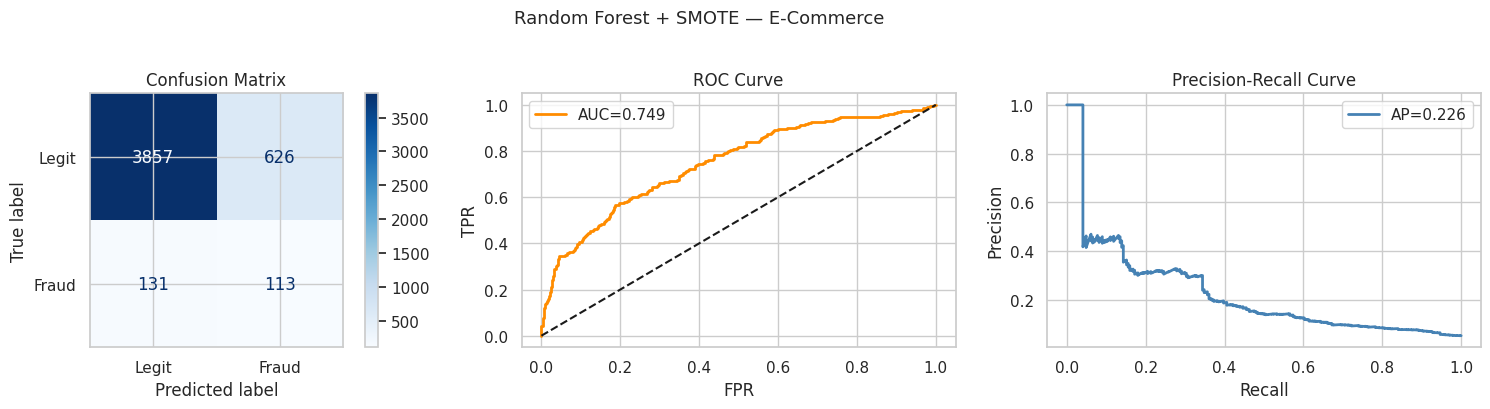

In [23]:
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf_smote.fit(X_ecom_sm, y_ecom_sm)

r = evaluate_model(rf_smote, X_ecom_te, y_ecom_te, 'Random Forest + SMOTE', 'E-Commerce')
results.append(r)

### 5.4 Random Forest — Credit Card

Random Forest | Credit Card
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9761
Avg Prec: 0.8343
F1 Score: 0.8229


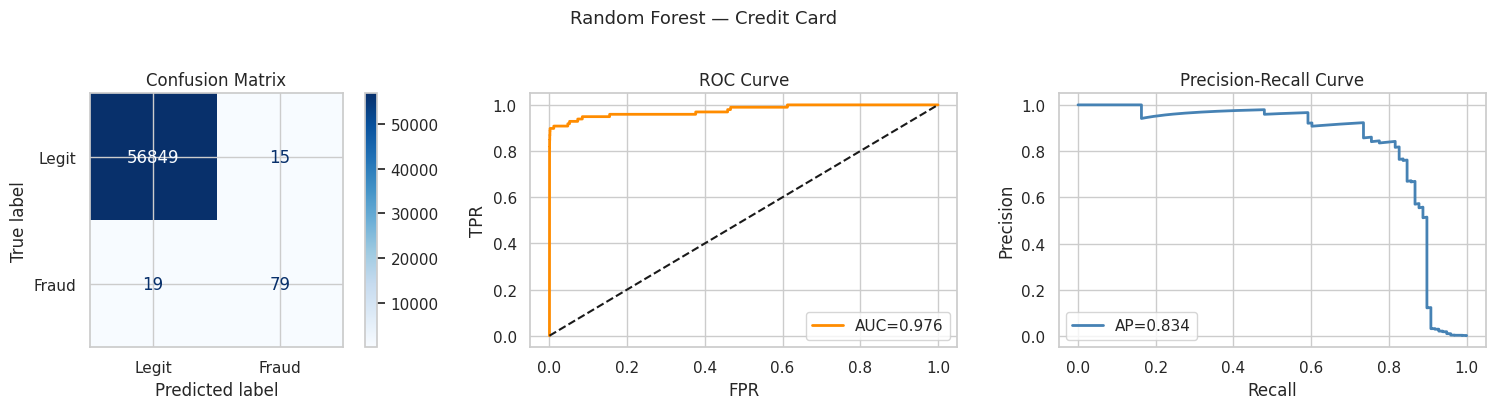

In [27]:
rf_cc = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)
rf_cc.fit(X_cc_tr, y_cc_tr)

r = evaluate_model(rf_cc, X_cc_te, y_cc_te, 'Random Forest', 'Credit Card')
results.append(r)

### 5.5 Random Forest — Transactions

Random Forest | Transactions
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.98     58617
       Fraud       0.31      0.89      0.46      1322

    accuracy                           0.95     59939
   macro avg       0.65      0.92      0.72     59939
weighted avg       0.98      0.95      0.96     59939

ROC-AUC : 0.9731
Avg Prec: 0.7466
F1 Score: 0.4561


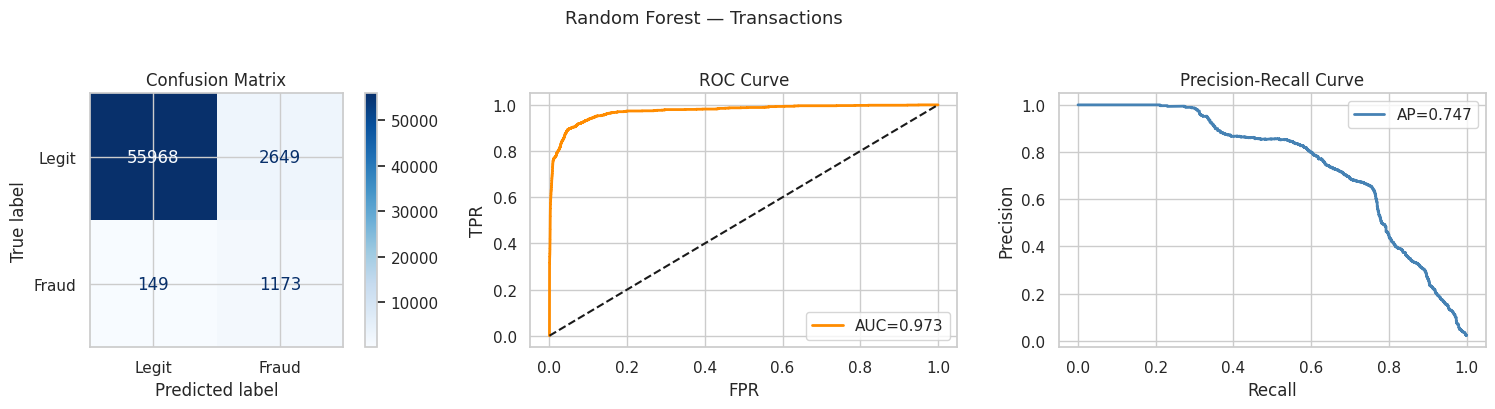

In [29]:
rf_txn = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_txn.fit(X_txn_tr, y_txn_tr)

r = evaluate_model(rf_txn, X_txn_te, y_txn_te, 'Random Forest', 'Transactions')
results.append(r)

---
## ⚡ 6. XGBoost

XGBoost's `scale_pos_weight` parameter is the recommended way to handle class imbalance:
```
scale_pos_weight = count(negative) / count(positive)
```

### 6.1 XGBoost — E-Commerce (with scale_pos_weight)

scale_pos_weight (E-Commerce): 18.33
[0]	validation_0-aucpr:0.31651
[100]	validation_0-aucpr:0.37664
[200]	validation_0-aucpr:0.37144
[299]	validation_0-aucpr:0.36219
XGBoost | E-Commerce
              precision    recall  f1-score   support

       Legit       0.97      0.91      0.94      4483
       Fraud       0.23      0.51      0.32       244

    accuracy                           0.89      4727
   macro avg       0.60      0.71      0.63      4727
weighted avg       0.93      0.89      0.91      4727

ROC-AUC : 0.7984
Avg Prec: 0.3631
F1 Score: 0.3208


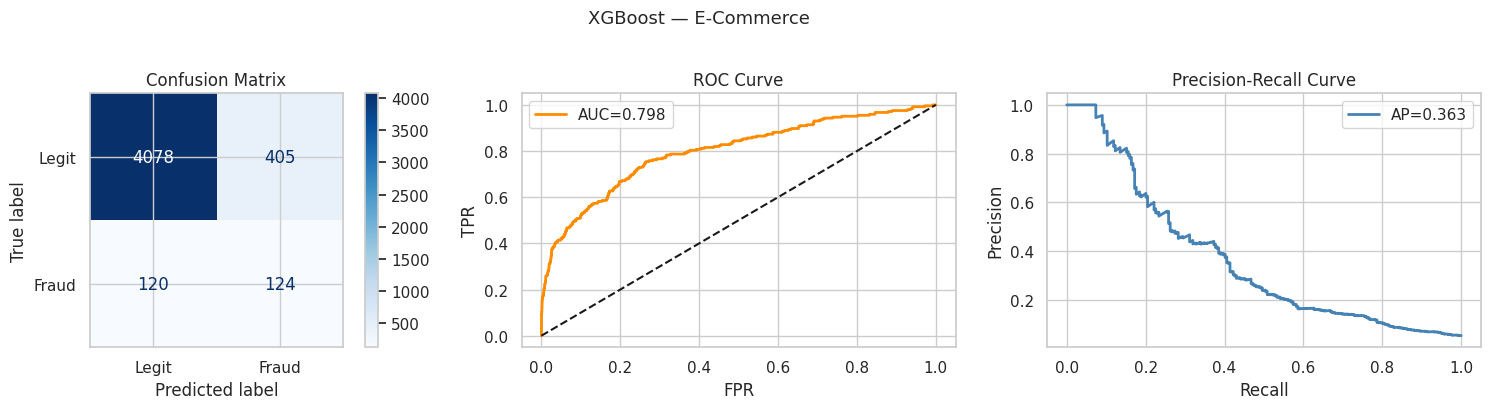

In [30]:
scale_pos_ecom = (y_ecom_tr == 0).sum() / (y_ecom_tr == 1).sum()
print(f'scale_pos_weight (E-Commerce): {scale_pos_ecom:.2f}')

xgb_ecom = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_ecom,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_ecom.fit(
    X_ecom_tr, y_ecom_tr,
    eval_set=[(X_ecom_te, y_ecom_te)],
    verbose=100
)
r = evaluate_model(xgb_ecom, X_ecom_te, y_ecom_te, 'XGBoost', 'E-Commerce')
results.append(r)

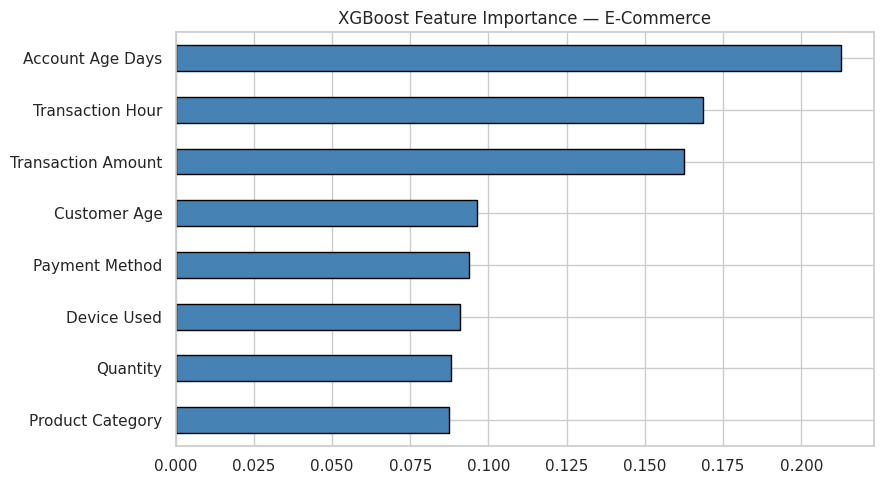

In [31]:
plot_feature_importance(xgb_ecom, X_ecom.columns, title='XGBoost Feature Importance — E-Commerce')

### 6.2 XGBoost + SMOTE — E-Commerce

XGBoost + SMOTE | E-Commerce
              precision    recall  f1-score   support

       Legit       0.97      0.87      0.91      4483
       Fraud       0.16      0.46      0.24       244

    accuracy                           0.85      4727
   macro avg       0.56      0.66      0.58      4727
weighted avg       0.93      0.85      0.88      4727

ROC-AUC : 0.7321
Avg Prec: 0.2583
F1 Score: 0.2360


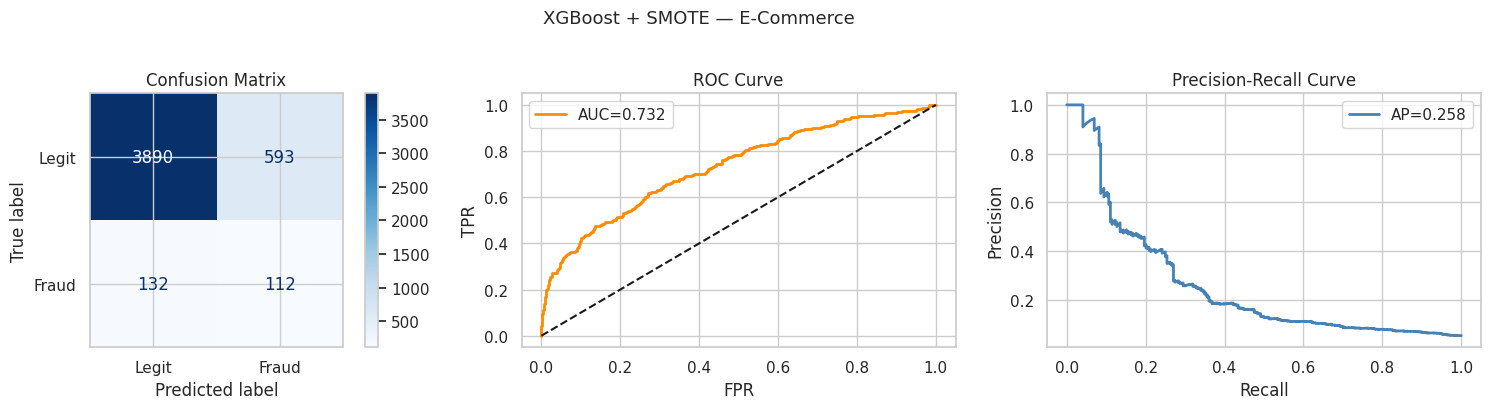

In [32]:
xgb_smote_ecom = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_smote_ecom.fit(X_ecom_sm, y_ecom_sm, verbose=False)
r = evaluate_model(xgb_smote_ecom, X_ecom_te, y_ecom_te, 'XGBoost + SMOTE', 'E-Commerce')
results.append(r)

### 6.3 XGBoost — Credit Card

scale_pos_weight (Credit Card): 577.29
[0]	validation_0-aucpr:0.37875
[100]	validation_0-aucpr:0.72557
[200]	validation_0-aucpr:0.81925
[300]	validation_0-aucpr:0.84443
[400]	validation_0-aucpr:0.85786
[499]	validation_0-aucpr:0.86675
XGBoost | Credit Card
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.73      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9803
Avg Prec: 0.8669
F1 Score: 0.7887


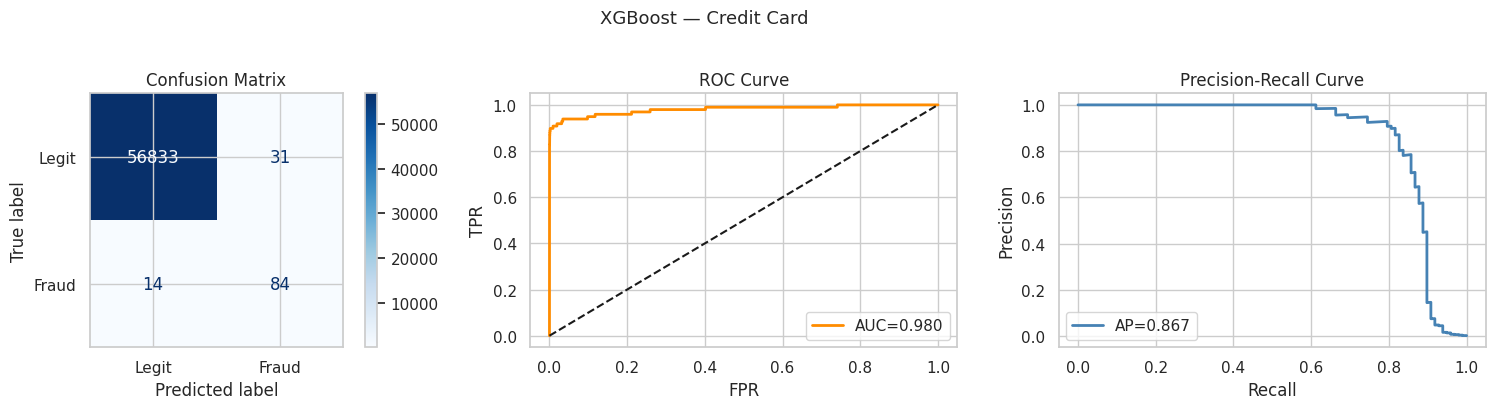

In [33]:
scale_pos_cc = (y_cc_tr == 0).sum() / (y_cc_tr == 1).sum()
print(f'scale_pos_weight (Credit Card): {scale_pos_cc:.2f}')

xgb_cc = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=scale_pos_cc,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_cc.fit(
    X_cc_tr, y_cc_tr,
    eval_set=[(X_cc_te, y_cc_te)],
    verbose=100
)
r = evaluate_model(xgb_cc, X_cc_te, y_cc_te, 'XGBoost', 'Credit Card')
results.append(r)

### 6.4 XGBoost — Transactions

scale_pos_weight (Transactions): 44.32
[0]	validation_0-aucpr:0.66604
[100]	validation_0-aucpr:0.84620
[200]	validation_0-aucpr:0.84976
[299]	validation_0-aucpr:0.85029
XGBoost | Transactions
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     58617
       Fraud       0.35      0.89      0.50      1322

    accuracy                           0.96     59939
   macro avg       0.67      0.93      0.74     59939
weighted avg       0.98      0.96      0.97     59939

ROC-AUC : 0.9766
Avg Prec: 0.8503
F1 Score: 0.5021


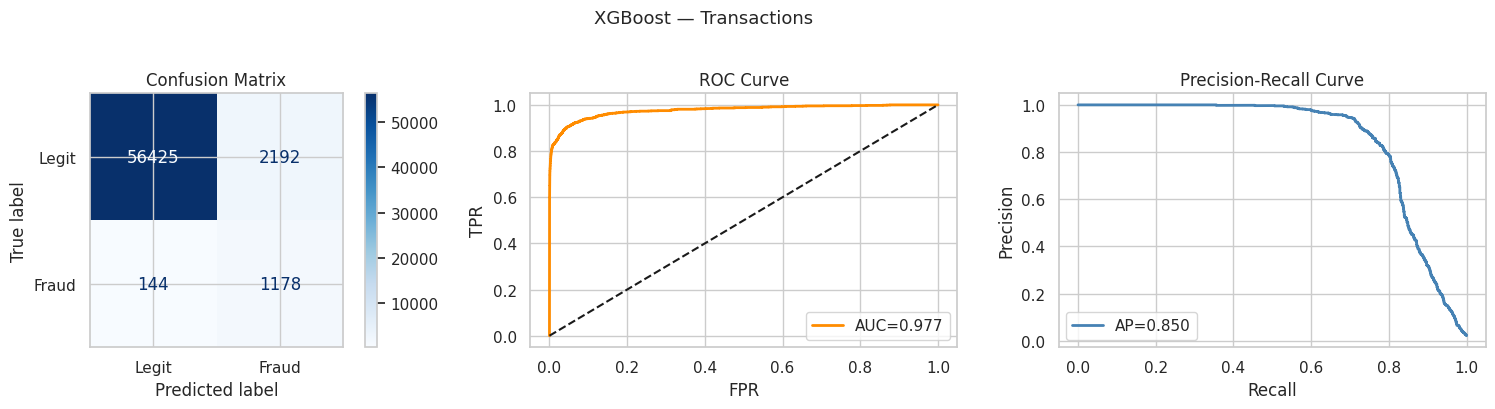

In [34]:
scale_pos_txn = (y_txn_tr == 0).sum() / (y_txn_tr == 1).sum()
print(f'scale_pos_weight (Transactions): {scale_pos_txn:.2f}')

xgb_txn = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_txn,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_txn.fit(
    X_txn_tr, y_txn_tr,
    eval_set=[(X_txn_te, y_txn_te)],
    verbose=100
)
r = evaluate_model(xgb_txn, X_txn_te, y_txn_te, 'XGBoost', 'Transactions')
results.append(r)

---
## 🔍 7. Isolation Forest — Unsupervised Anomaly Detection

Isolation Forest works by randomly partitioning data. **Anomalies** are isolated in fewer splits — they have shorter average path lengths through the trees.

- `contamination` = expected proportion of anomalies (set to true fraud rate)
- Returns: `1` = normal, `-1` = anomaly → we remap to `0/1`

### 7.1 Isolation Forest — Credit Card (most extreme imbalance)

In [35]:
contamination_cc = y_cc.mean()  # true fraud rate
print(f'Contamination (Credit Card): {contamination_cc:.5f}')

iso_cc = IsolationForest(
    n_estimators=200,
    contamination=contamination_cc,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_cc.fit(X_cc_tr)  # unsupervised — labels NOT used in training

# Predict on test set
raw_pred  = iso_cc.predict(X_cc_te)           # 1 = normal, -1 = anomaly
y_iso_cc  = np.where(raw_pred == -1, 1, 0)    # remap: fraud=1
iso_score = iso_cc.score_samples(X_cc_te)      # anomaly score (lower = more anomalous)
iso_prob  = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min())  # normalise 0-1
iso_prob  = 1 - iso_prob  # flip: higher = more fraudulent

print('\n--- Isolation Forest | Credit Card ---')
print(classification_report(y_cc_te, y_iso_cc, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_cc_te, iso_prob):.4f}')

Contamination (Credit Card): 0.00173

--- Isolation Forest | Credit Card ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.25      0.28      0.26        98

    accuracy                           1.00     56962
   macro avg       0.62      0.64      0.63     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9529


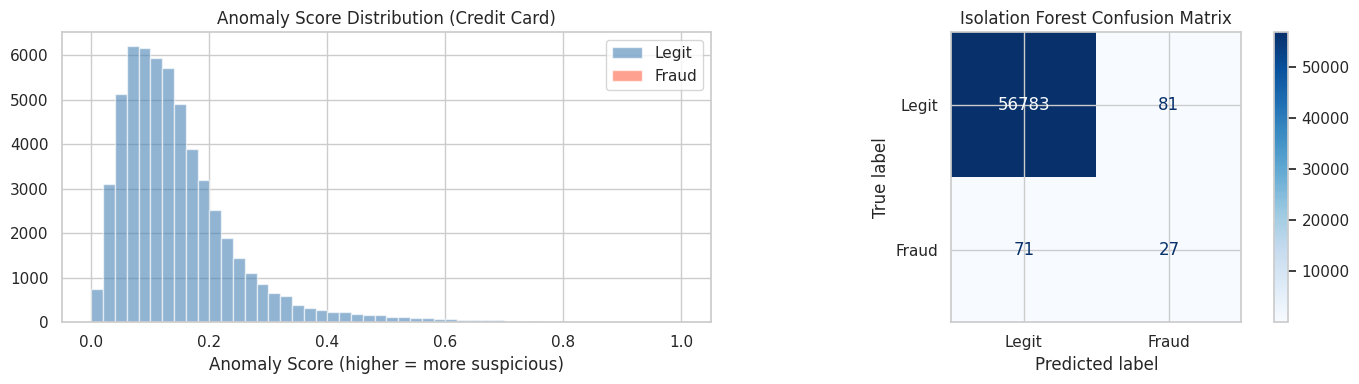

In [36]:
# Visualise anomaly scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Score distribution
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_cc_te == label
    axes[0].hist(iso_prob[mask], bins=50, alpha=0.6, color=color,
                 label='Legit' if label==0 else 'Fraud')
axes[0].set_title('Anomaly Score Distribution (Credit Card)')
axes[0].legend()
axes[0].set_xlabel('Anomaly Score (higher = more suspicious)')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_cc_te, y_iso_cc, ax=axes[1],
    display_labels=['Legit', 'Fraud'], cmap='Blues'
)
axes[1].set_title('Isolation Forest Confusion Matrix')

plt.tight_layout()
plt.show()

### 7.2 Isolation Forest — E-Commerce

In [37]:
contamination_ecom = y_ecom.mean()
print(f'Contamination (E-Commerce): {contamination_ecom:.5f}')

iso_ecom = IsolationForest(
    n_estimators=200,
    contamination=contamination_ecom,
    random_state=42,
    n_jobs=-1
)
iso_ecom.fit(X_ecom_tr)

raw_pred_ecom = iso_ecom.predict(X_ecom_te)
y_iso_ecom    = np.where(raw_pred_ecom == -1, 1, 0)
iso_score_ecom = iso_ecom.score_samples(X_ecom_te)
iso_prob_ecom  = 1 - (iso_score_ecom - iso_score_ecom.min()) / (iso_score_ecom.max() - iso_score_ecom.min())

print('\n--- Isolation Forest | E-Commerce ---')
print(classification_report(y_ecom_te, y_iso_ecom, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_ecom_te, iso_prob_ecom):.4f}')

Contamination (E-Commerce): 0.05171

--- Isolation Forest | E-Commerce ---
              precision    recall  f1-score   support

       Legit       0.96      0.95      0.95      4483
       Fraud       0.19      0.23      0.21       244

    accuracy                           0.91      4727
   macro avg       0.58      0.59      0.58      4727
weighted avg       0.92      0.91      0.91      4727

ROC-AUC: 0.6729


### 7.3 Isolation Forest — Transactions

In [38]:
contamination_txn = y_txn.mean()

iso_txn = IsolationForest(
    n_estimators=200,
    contamination=contamination_txn,
    random_state=42,
    n_jobs=-1
)
iso_txn.fit(X_txn_tr)

raw_pred_txn = iso_txn.predict(X_txn_te)
y_iso_txn    = np.where(raw_pred_txn == -1, 1, 0)
iso_score_txn = iso_txn.score_samples(X_txn_te)
iso_prob_txn  = 1 - (iso_score_txn - iso_score_txn.min()) / (iso_score_txn.max() - iso_score_txn.min())

print('--- Isolation Forest | Transactions ---')
print(classification_report(y_txn_te, y_iso_txn, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_txn_te, iso_prob_txn):.4f}')

--- Isolation Forest | Transactions ---
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99     58617
       Fraud       0.41      0.39      0.40      1322

    accuracy                           0.97     59939
   macro avg       0.70      0.69      0.69     59939
weighted avg       0.97      0.97      0.97     59939

ROC-AUC: 0.9022


### 7.4 Hybrid: Isolation Forest → XGBoost (Two-Stage Pipeline)

In [40]:
"""
Two-Stage Pipeline:
  Stage 1: Isolation Forest filters out clear non-fraud (iso_score > threshold)
  Stage 2: XGBoost classifies the remaining (suspicious) subset

This reduces XGBoost's workload and can improve recall.
"""

# Stage 1: get anomaly scores on TRAIN set, use to pre-filter
iso_hybrid = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_hybrid.fit(X_cc_tr)

train_scores = iso_hybrid.score_samples(X_cc_tr)
# Keep samples with anomaly score below the 20th percentile (most suspicious 20%)
threshold = np.percentile(train_scores, 20)
keep_train = train_scores <= threshold

X_cc_filtered = X_cc_tr[keep_train]
y_cc_filtered = y_cc_tr[keep_train]

print(f'Samples kept after Isolation Forest filter: {keep_train.sum():,} / {len(X_cc_tr):,}')
print(f'Fraud rate in filtered set: {y_cc_filtered.mean():.4f}')

# Stage 2: XGBoost on filtered set
spw = (y_cc_filtered == 0).sum() / (y_cc_filtered == 1).sum()
xgb_hybrid = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=spw, use_label_encoder=False,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_hybrid.fit(X_cc_filtered, y_cc_filtered, verbose=False)

# Predict on FULL test set (two-stage)
test_scores = iso_hybrid.score_samples(X_cc_te)
suspicious  = test_scores <= threshold

y_hybrid_pred = np.zeros(len(X_cc_te), dtype=int)
if suspicious.sum() > 0:
    y_hybrid_pred[suspicious] = xgb_hybrid.predict(X_cc_te[suspicious])

print('\n--- Two-Stage Hybrid (IF + XGBoost) | Credit Card ---')
print(classification_report(y_cc_te, y_hybrid_pred, target_names=['Legit', 'Fraud']))
print(f'F1 Fraud: {f1_score(y_cc_te, y_hybrid_pred):.4f}')

Samples kept after Isolation Forest filter: 45,569 / 227,845
Fraud rate in filtered set: 0.0080

--- Two-Stage Hybrid (IF + XGBoost) | Credit Card ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.90      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

F1 Fraud: 0.8737


---
## 📊 8. Model Comparison Dashboard

In [41]:
# Collect all supervised model results into a summary table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(results_df.style.background_gradient(subset=['roc_auc','avg_precision','f1'], cmap='RdYlGn'))

,model,dataset,roc_auc,avg_precision,f1
0,XGBoost,Credit Card,0.980306,0.866930,0.788732
1,XGBoost,Transactions,0.976628,0.850311,0.502131
2,Random Forest,Credit Card,0.976059,0.834350,0.822917
3,Random Forest,Credit Card,0.976059,0.834350,0.822917
4,Random Forest,Transactions,0.973097,0.746601,0.456065
5,Random Forest,Transactions,0.973097,0.746601,0.456065
6,Random Forest,Transactions,0.973097,0.746601,0.456065
7,Random Forest (balanced),E-Commerce,0.810015,0.268151,0.334416
8,XGBoost,E-Commerce,0.798397,0.363067,0.320828
9,XGBoost,E-Commerce,0.798397,0.363067,0.320828


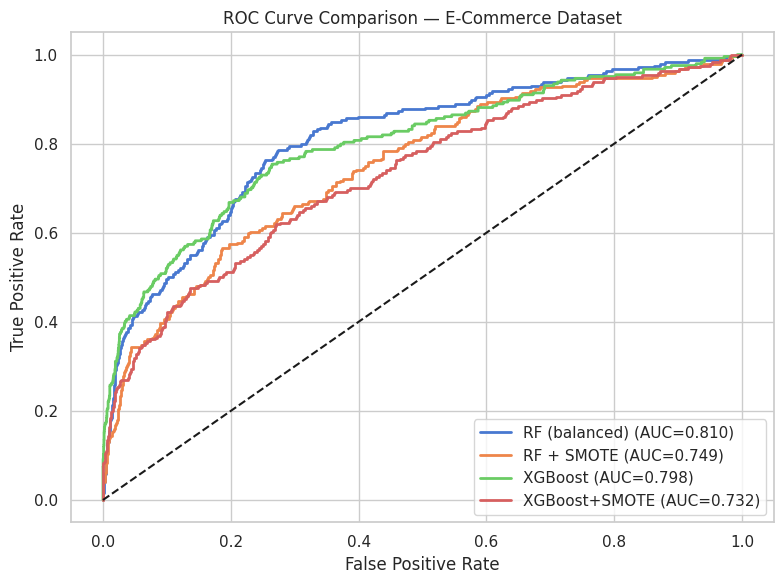

In [42]:
# Compare ROC curves side-by-side for E-Commerce dataset
models_ecom = {
    'RF (balanced)' : (rf_base,       X_ecom_te),
    'RF + SMOTE'    : (rf_smote,      X_ecom_te),
    'XGBoost'       : (xgb_ecom,      X_ecom_te),
    'XGBoost+SMOTE' : (xgb_smote_ecom, X_ecom_te),
}

plt.figure(figsize=(8, 6))
for name, (model, X_te) in models_ecom.items():
    prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_ecom_te, prob)
    auc = roc_auc_score(y_ecom_te, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — E-Commerce Dataset')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

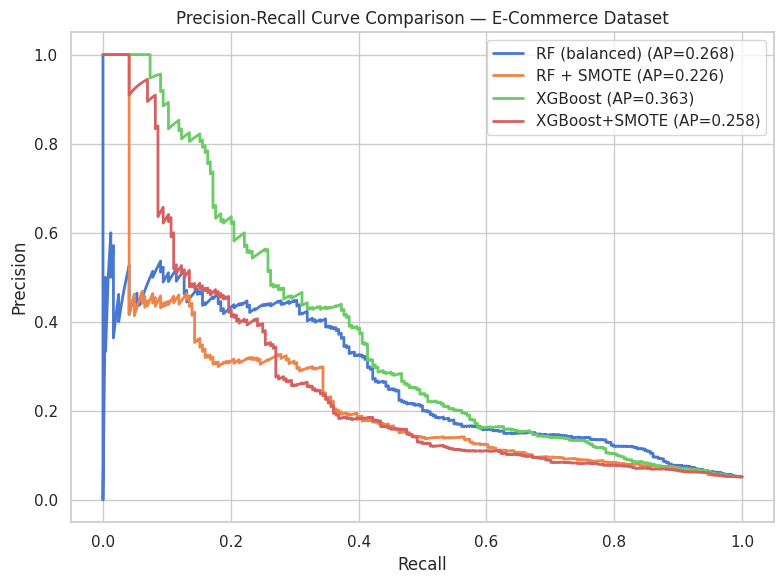

In [43]:
# Compare PR curves — E-Commerce
plt.figure(figsize=(8, 6))
for name, (model, X_te) in models_ecom.items():
    prob = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_ecom_te, prob)
    ap = average_precision_score(y_ecom_te, prob)
    plt.plot(rec, prec, lw=2, label=f'{name} (AP={ap:.3f})')

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison — E-Commerce Dataset')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔄 9. Cross-Validation with Stratified K-Fold

In [44]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Using ImbPipeline so SMOTE is applied correctly within each fold
pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42))
])

pipe_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                            use_label_encoder=False, eval_metric='logloss',
                            random_state=42, n_jobs=-1))
])

scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'avg_precision': 'average_precision'}

print('Running 5-Fold CV on E-Commerce (this may take a minute)...')

cv_rf  = cross_validate(pipe_rf,  X_ecom, y_ecom, cv=skf, scoring=scoring, n_jobs=-1)
cv_xgb = cross_validate(pipe_xgb, X_ecom, y_ecom, cv=skf, scoring=scoring, n_jobs=-1)

cv_summary = pd.DataFrame({
    'RF+SMOTE (mean)'   : {k: cv_rf[f'test_{k}'].mean() for k in scoring},
    'RF+SMOTE (std)'    : {k: cv_rf[f'test_{k}'].std()  for k in scoring},
    'XGB+SMOTE (mean)'  : {k: cv_xgb[f'test_{k}'].mean() for k in scoring},
    'XGB+SMOTE (std)'   : {k: cv_xgb[f'test_{k}'].std()  for k in scoring},
}).T
display(cv_summary.round(4))

Running 5-Fold CV on E-Commerce (this may take a minute)...


,roc_auc,f1,avg_precision
RF+SMOTE (mean),0.7641,0.2560,0.2504
RF+SMOTE (std),0.0168,0.0087,0.0062
XGB+SMOTE (mean),0.7565,0.2451,0.3003
XGB+SMOTE (std),0.0206,0.0107,0.0204


---
## 🎯 10. Threshold Tuning

Default threshold of 0.5 is rarely optimal for fraud detection. We can tune to maximise F1 or set a business-specific recall target.

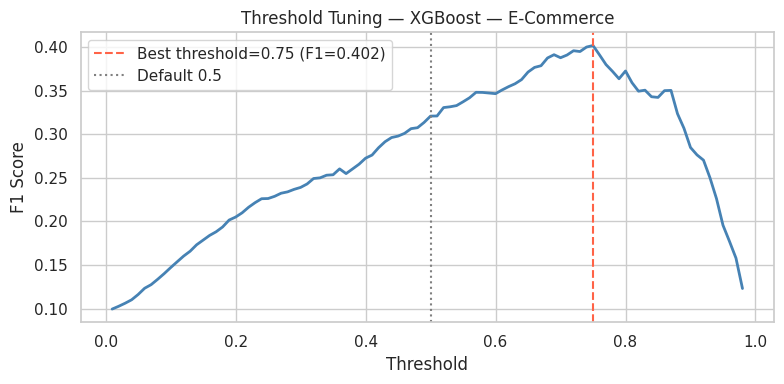

Default (0.5)  F1: 0.3208
Optimal (0.75) F1: 0.4018


In [45]:
def tune_threshold(model, X_test, y_test, metric='f1', title=''):
    """Find threshold maximising a metric, or guaranteeing a recall target."""
    proba = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.01, 0.99, 0.01)

    scores = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        scores.append(f1_score(y_test, preds, zero_division=0))

    best_t = thresholds[np.argmax(scores)]
    best_f1 = max(scores)

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, scores, color='steelblue', lw=2)
    plt.axvline(best_t, color='tomato', linestyle='--', label=f'Best threshold={best_t:.2f} (F1={best_f1:.3f})')
    plt.axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
    plt.xlabel('Threshold'); plt.ylabel('F1 Score')
    plt.title(f'Threshold Tuning — {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'Default (0.5)  F1: {f1_score(y_test, (proba>=0.5).astype(int)):.4f}')
    print(f'Optimal ({best_t:.2f}) F1: {best_f1:.4f}')
    return best_t

best_t_xgb = tune_threshold(xgb_ecom, X_ecom_te, y_ecom_te, title='XGBoost — E-Commerce')

In [46]:
# Apply best threshold
proba_xgb = xgb_ecom.predict_proba(X_ecom_te)[:, 1]
y_tuned   = (proba_xgb >= best_t_xgb).astype(int)

print(f'\nClassification Report at threshold={best_t_xgb:.2f}:')
print(classification_report(y_ecom_te, y_tuned, target_names=['Legit', 'Fraud']))


Classification Report at threshold=0.75:
              precision    recall  f1-score   support

       Legit       0.97      0.97      0.97      4483
       Fraud       0.44      0.37      0.40       244

    accuracy                           0.94      4727
   macro avg       0.70      0.67      0.69      4727
weighted avg       0.94      0.94      0.94      4727



---
## 💾 11. Save Best Models

In [47]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

joblib.dump(rf_base,    'saved_models/rf_ecom_balanced.pkl')
joblib.dump(rf_smote,   'saved_models/rf_ecom_smote.pkl')
joblib.dump(xgb_ecom,   'saved_models/xgb_ecom.pkl')
joblib.dump(rf_cc,      'saved_models/rf_creditcard.pkl')
joblib.dump(xgb_cc,     'saved_models/xgb_creditcard.pkl')
joblib.dump(iso_cc,     'saved_models/isolation_forest_creditcard.pkl')
joblib.dump(rf_txn,     'saved_models/rf_transactions.pkl')
joblib.dump(xgb_txn,    'saved_models/xgb_transactions.pkl')

print('✅ All models saved to saved_models/')

✅ All models saved to saved_models/


---
## 🏁 12. Summary & Recommendations

| Technique | When to Use |
|-----------|-------------|
| **Random Forest + class_weight='balanced'** | Quick baseline; interpretable feature importances; robust to noise |
| **Random Forest + SMOTE** | When recall matters more than precision; moderate imbalance |
| **XGBoost + scale_pos_weight** | Best accuracy/speed tradeoff; handles large datasets well |
| **XGBoost + SMOTE** | Extreme imbalance (<0.5% fraud); combine with threshold tuning |
| **Isolation Forest** | No labeled fraud data available; real-time anomaly scoring |
| **IF → XGBoost Hybrid** | High-volume systems: use IF to pre-filter, XGBoost to classify suspects |

### Key takeaways
- **ROC-AUC** can be misleading for extreme imbalance → prefer **Average Precision (PR-AUC)**
- **Threshold tuning** often gives more practical gains than model switching
- **SMOTE must always be applied inside CV folds** (use `imblearn.pipeline`)
- **Isolation Forest** shines when labeled data is scarce but degrades fast with many features